# Análise Exploratória de Dados (EDA)

## Objetivo

Esta etapa tem como objetivo compreender a estrutura e a qualidade dos dados antes do desenvolvimento dos modelos de Machine Learning para análise de risco de crédito.

Ao longo desta análise serão investigadas as características da base de dados, a distribuição da variável alvo, o perfil dos clientes, possíveis problemas de qualidade dos dados e as relações entre as variáveis explicativas e o risco de inadimplência.

Os insights obtidos nesta fase servirão como base para as etapas de engenharia de atributos, seleção de modelos e interpretação dos resultados.

---

## Objetivos específicos

- Compreender a estrutura do conjunto de dados;
- Avaliar a qualidade dos dados (valores ausentes, duplicidades e consistência);
- Analisar a distribuição da variável alvo;
- Caracterizar o perfil dos clientes;
- Investigar relações entre as variáveis e o risco de crédito;
- Identificar possíveis hipóteses para a etapa de modelagem;
- Documentar os principais insights de negócio obtidos durante a análise.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from credit_scoring_mlops.data.load_data import load_credit_data
from credit_scoring_mlops.data.validation import validate_dataset

In [2]:
df = load_credit_data()
df.shape

(1000, 21)

## Validação da Base de Dados

Nesta etapa serão avaliados aspectos como:

- Quantidade de registros e variáveis;
- Valores ausentes;
- Registros duplicados;
- Consistência geral da base.

Essa verificação garante que a análise seja realizada sobre um conjunto de dados íntegro e confiável.

In [3]:
validation_report = validate_dataset(df)

validation_report

{'is_empty': False,
 'rows': 1000,
 'columns': 21,
 'missing_values': 0,
 'duplicate_rows': 0}

## Entendimento das Variáveis

Antes da análise exploratória, é importante compreender o significado de cada variável presente no conjunto de dados.

Essa etapa facilita a interpretação dos resultados, auxilia na identificação de possíveis problemas de qualidade e fornece contexto para as decisões de engenharia de atributos e modelagem.

A tabela abaixo resume as principais características de cada variável utilizada neste projeto.

In [4]:
data_dictionary = pd.DataFrame(
    {
        "Variável": [
            "status",
            "duration",
            "credit_history",
            "purpose",
            "amount",
            "savings",
            "employment_duration",
            "installment_rate",
            "personal_status_sex",
            "other_debtors",
            "present_residence",
            "property",
            "age",
            "other_installment_plans",
            "housing",
            "existing_credits",
            "job",
            "people_liable",
            "telephone",
            "foreign_worker",
            "credit_risk",
        ],
        "Tipo": [
            "Categórica",
            "Numérica",
            "Categórica",
            "Categórica",
            "Numérica",
            "Categórica",
            "Categórica",
            "Numérica",
            "Categórica",
            "Categórica",
            "Numérica",
            "Categórica",
            "Numérica",
            "Categórica",
            "Categórica",
            "Numérica",
            "Categórica",
            "Numérica",
            "Categórica",
            "Categórica",
            "Binária",
        ],
        "Natureza": [
            "Nominal",
            "Discreta",
            "Ordinal",
            "Nominal",
            "Contínua",
            "Ordinal",
            "Ordinal",
            "Discreta",
            "Nominal",
            "Nominal",
            "Discreta",
            "Nominal",
            "Contínua",
            "Nominal",
            "Nominal",
            "Discreta",
            "Nominal",
            "Discreta",
            "Binária",
            "Binária",
            "Variável Alvo",
        ],
        "Descrição": [
            "Situação da conta corrente.",
            "Duração do empréstimo (meses).",
            "Histórico de crédito do cliente.",
            "Finalidade do empréstimo.",
            "Valor do crédito solicitado.",
            "Valor disponível em poupança.",
            "Tempo de emprego atual.",
            "Percentual da renda comprometida com as parcelas.",
            "Estado civil e sexo.",
            "Existência de fiador ou coobrigado.",
            "Tempo de residência atual.",
            "Tipo de patrimônio.",
            "Idade do cliente.",
            "Outros planos de financiamento.",
            "Tipo de moradia.",
            "Quantidade de créditos existentes.",
            "Profissão do cliente.",
            "Número de pessoas dependentes.",
            "Possui telefone.",
            "É trabalhador estrangeiro.",
            "Classificação do risco de crédito.",
        ],
        "Exemplo": [
            "< 0 DM",
            "24",
            "Sem atrasos",
            "Automóvel",
            "3500",
            "100–500 DM",
            "4–7 anos",
            "4",
            "Masculino solteiro",
            "Nenhum",
            "2",
            "Imóvel",
            "35",
            "Banco",
            "Própria",
            "1",
            "Especializado",
            "1",
            "Sim",
            "Não",
            "Bom",
        ],
        "Papel": [
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Feature",
            "Target",
        ],
    }
)

data_dictionary

,Variável,Tipo,Natureza,Descrição,Exemplo,Papel
0,status,Categórica,Nominal,Situação da conta corrente.,< 0 DM,Feature
1,duration,Numérica,Discreta,Duração do empréstimo (meses).,24,Feature
2,credit_history,Categórica,Ordinal,Histórico de crédito do cliente.,Sem atrasos,Feature
3,purpose,Categórica,Nominal,Finalidade do empréstimo.,Automóvel,Feature
4,amount,Numérica,Contínua,Valor do crédito solicitado.,3500,Feature
5,savings,Categórica,Ordinal,Valor disponível em poupança.,100–500 DM,Feature
6,employment_duration,Categórica,Ordinal,Tempo de emprego atual.,4–7 anos,Feature
7,installment_rate,Numérica,Discreta,Percentual da renda comprometida com as parcelas.,4,Feature
8,personal_status_sex,Categórica,Nominal,Estado civil e sexo.,Masculino solteiro,Feature
9,other_debtors,Categórica,Nominal,Existência de fiador ou coobrigado.,Nenhum,Feature


## Análise da Variável Alvo


In [5]:
df["credit_risk"].value_counts().sort_index()

credit_risk
0    300
1    700
Name: count, dtype: int64

In [6]:
(
    df["credit_risk"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .rename("Percentual (%)")
)

credit_risk
0    30.0
1    70.0
Name: Percentual (%), dtype: float64

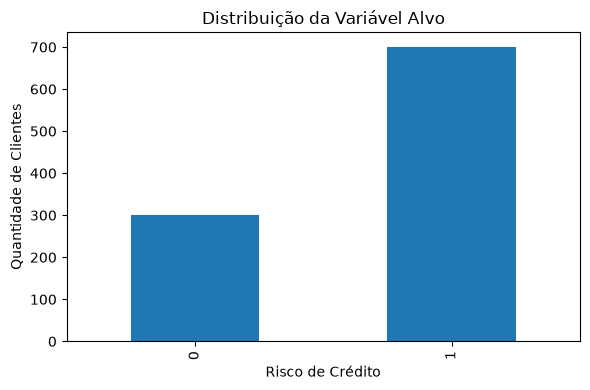

In [7]:
ax = (
    df["credit_risk"]
    .value_counts()
    .sort_index()
    .plot(
        kind="bar",
        figsize=(6, 4),
    )
)

ax.set_title("Distribuição da Variável Alvo")
ax.set_xlabel("Risco de Crédito")
ax.set_ylabel("Quantidade de Clientes")

plt.tight_layout()
plt.show()

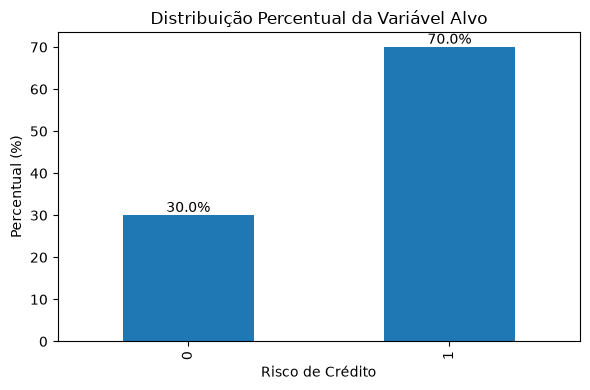

In [8]:
target_distribution = (
    df["credit_risk"].value_counts(normalize=True).sort_index().mul(100)
)

ax = target_distribution.plot(
    kind="bar",
    figsize=(6, 4),
)

ax.set_title("Distribuição Percentual da Variável Alvo")
ax.set_xlabel("Risco de Crédito")
ax.set_ylabel("Percentual (%)")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

## Classificação das Variáveis

Neste conjunto de dados, as variáveis foram divididas em:

- **Variáveis numéricas:** representam valores quantitativos.
- **Variáveis categóricas:** representam categorias ou classes.
- **Variável alvo:** utilizada para treinamento dos modelos de classificação.


In [9]:
target = "credit_risk"

numeric_features = [
    "duration",
    "amount",
    "installment_rate",
    "residence_duration",
    "age",
    "existing_credits",
    "people_liable",
]

categorical_features = [
    column for column in df.columns if column not in numeric_features + [target]
]

print(f"Variáveis numéricas ({len(numeric_features)}):")
print(numeric_features)

print()

print(f"Variáveis categóricas ({len(categorical_features)}):")
print(categorical_features)

Variáveis numéricas (7):
['duration', 'amount', 'installment_rate', 'residence_duration', 'age', 'existing_credits', 'people_liable']

Variáveis categóricas (15):
['checking_account', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_duration', 'personal_status_sex', 'guarantors', 'property', 'other_installment_plans', 'housing', 'job', 'telef', 'foreign_worker']


## Análise Univariada das Variáveis Numéricas

In [11]:
numeric_features = [
    "duration_months",
    "credit_amount",
    "installment_rate",
    "residence_duration",
    "age",
    "existing_credits",
    "people_liable",
]

numeric_features

['duration_months',
 'credit_amount',
 'installment_rate',
 'residence_duration',
 'age',
 'existing_credits',
 'people_liable']

In [12]:
numeric_summary = df[numeric_features].describe().T

numeric_summary["median"] = df[numeric_features].median()
numeric_summary["skewness"] = df[numeric_features].skew()
numeric_summary["kurtosis"] = df[numeric_features].kurt()

numeric_summary = numeric_summary[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "skewness",
        "kurtosis",
    ]
].round(2)

numeric_summary

,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
duration_months,1000.0,20.90,18.0,12.06,4.0,12.0,18.0,24.00,72.0,1.09,0.92
credit_amount,1000.0,3271.25,2319.5,2822.75,250.0,1365.5,2319.5,3972.25,18424.0,1.95,4.29
installment_rate,1000.0,2.97,3.0,1.12,1.0,2.0,3.0,4.00,4.0,-0.53,-1.21
residence_duration,1000.0,2.84,3.0,1.10,1.0,2.0,3.0,4.00,4.0,-0.27,-1.38
age,1000.0,35.54,33.0,11.35,19.0,27.0,33.0,42.00,75.0,1.02,0.62
existing_credits,1000.0,1.41,1.0,0.58,1.0,1.0,1.0,2.00,4.0,1.27,1.60
people_liable,1000.0,1.84,2.0,0.36,1.0,2.0,2.0,2.00,2.0,-1.91,1.65


### Distribuição das Variáveis Numéricas

Após a análise das estatísticas descritivas, foram construídos histogramas para visualizar a distribuição de cada variável numérica.

Essa análise permite identificar padrões como assimetria, concentração de valores, multimodalidade e possíveis valores extremos que podem influenciar o desempenho dos modelos de Machine Learning.

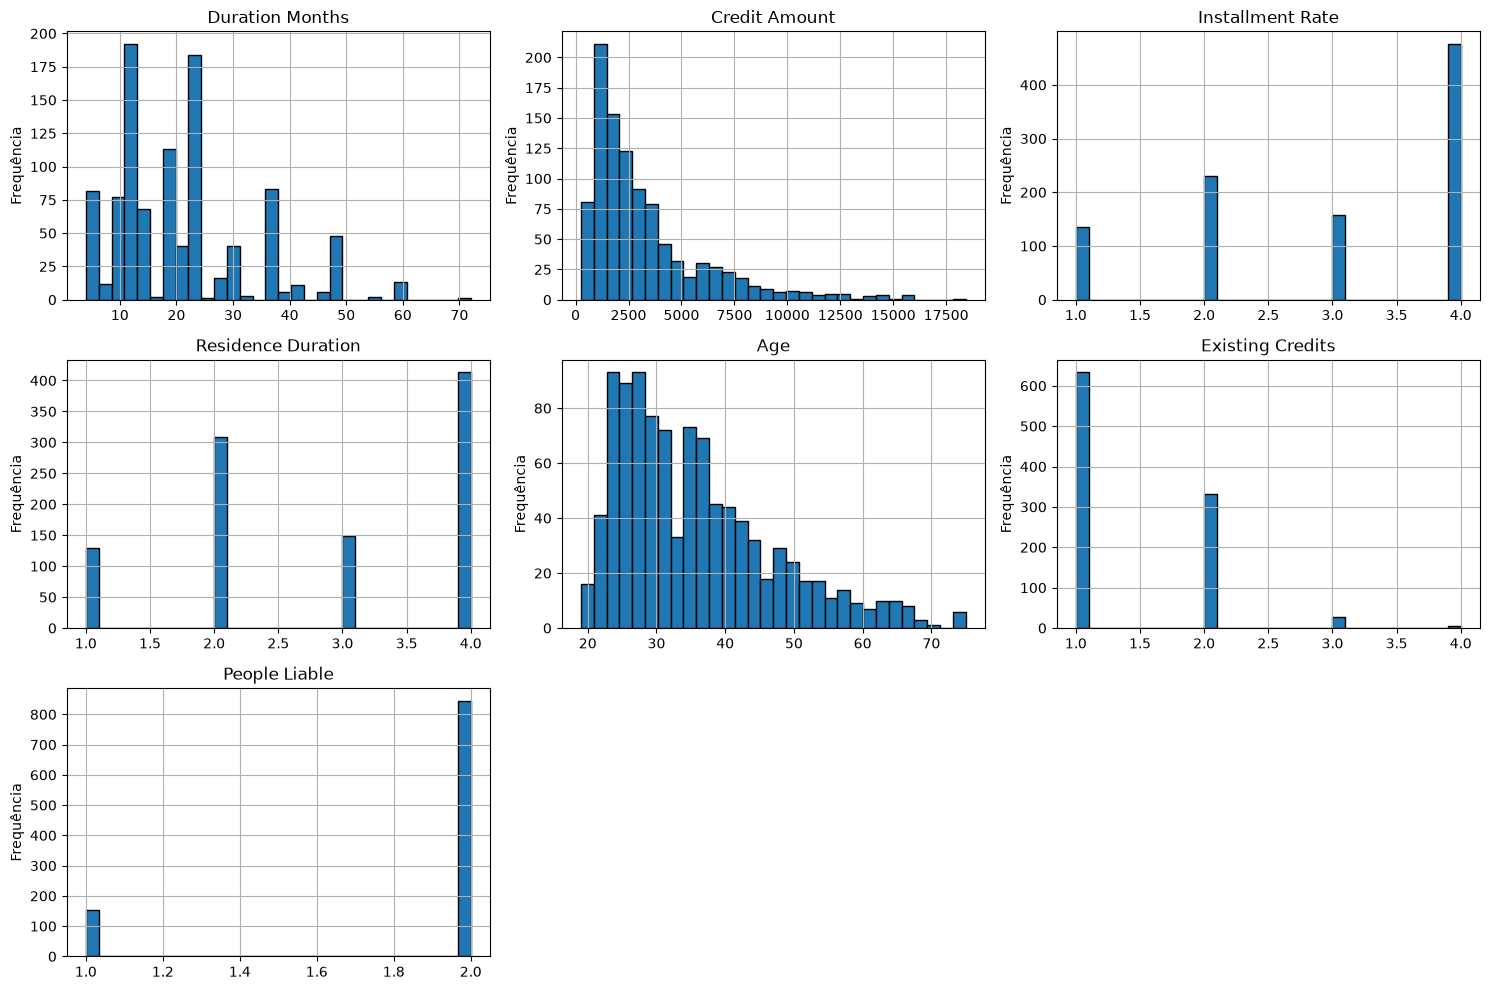

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, column in zip(axes, numeric_features, strict=False):
    df[column].hist(
        bins=30,
        ax=ax,
        edgecolor="black",
    )

    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Frequência")

# Remove eixos vazios
for ax in axes[len(numeric_features) :]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Interpretação

A análise dos histogramas permite observar diferentes padrões de distribuição entre as variáveis numéricas.

- **Duration Months:** apresenta distribuição assimétrica à direita, indicando predominância de empréstimos com prazos mais curtos e poucos contratos de longa duração.

- **Credit Amount:** possui forte assimetria positiva, concentrando a maior parte dos empréstimos em valores menores, enquanto poucos clientes solicitaram valores elevados.

- **Installment Rate:** trata-se de uma variável discreta, com poucos valores possíveis e maior concentração nas categorias mais altas.

- **Residence Duration:** também apresenta distribuição discreta, indicando que a maioria dos clientes possui maior tempo de residência no endereço atual.

- **Age:** apresenta distribuição assimétrica à direita, com predominância de clientes adultos entre aproximadamente 25 e 40 anos e menor frequência de clientes mais idosos.

- **Existing Credits:** observa-se forte concentração em clientes que possuem apenas um ou dois créditos ativos, enquanto poucos clientes apresentam múltiplos créditos simultaneamente.

- **People Liable:** praticamente todos os clientes possuem uma ou duas pessoas financeiramente dependentes, resultando em baixa variabilidade dessa variável.

De forma geral, observa-se que várias variáveis apresentam distribuições assimétricas ou discretas, característica comum em bases de crédito. Esses padrões serão considerados durante as próximas etapas de engenharia de atributos e modelagem.

## Identificação de Valores Extremos (Outliers)

Após analisar a distribuição das variáveis numéricas, serão utilizados boxplots para identificar possíveis valores extremos.

Embora algoritmos baseados em árvores sejam relativamente robustos à presença de outliers, sua identificação é importante para compreender melhor o comportamento da base e avaliar a necessidade de tratamentos específicos em etapas futuras.


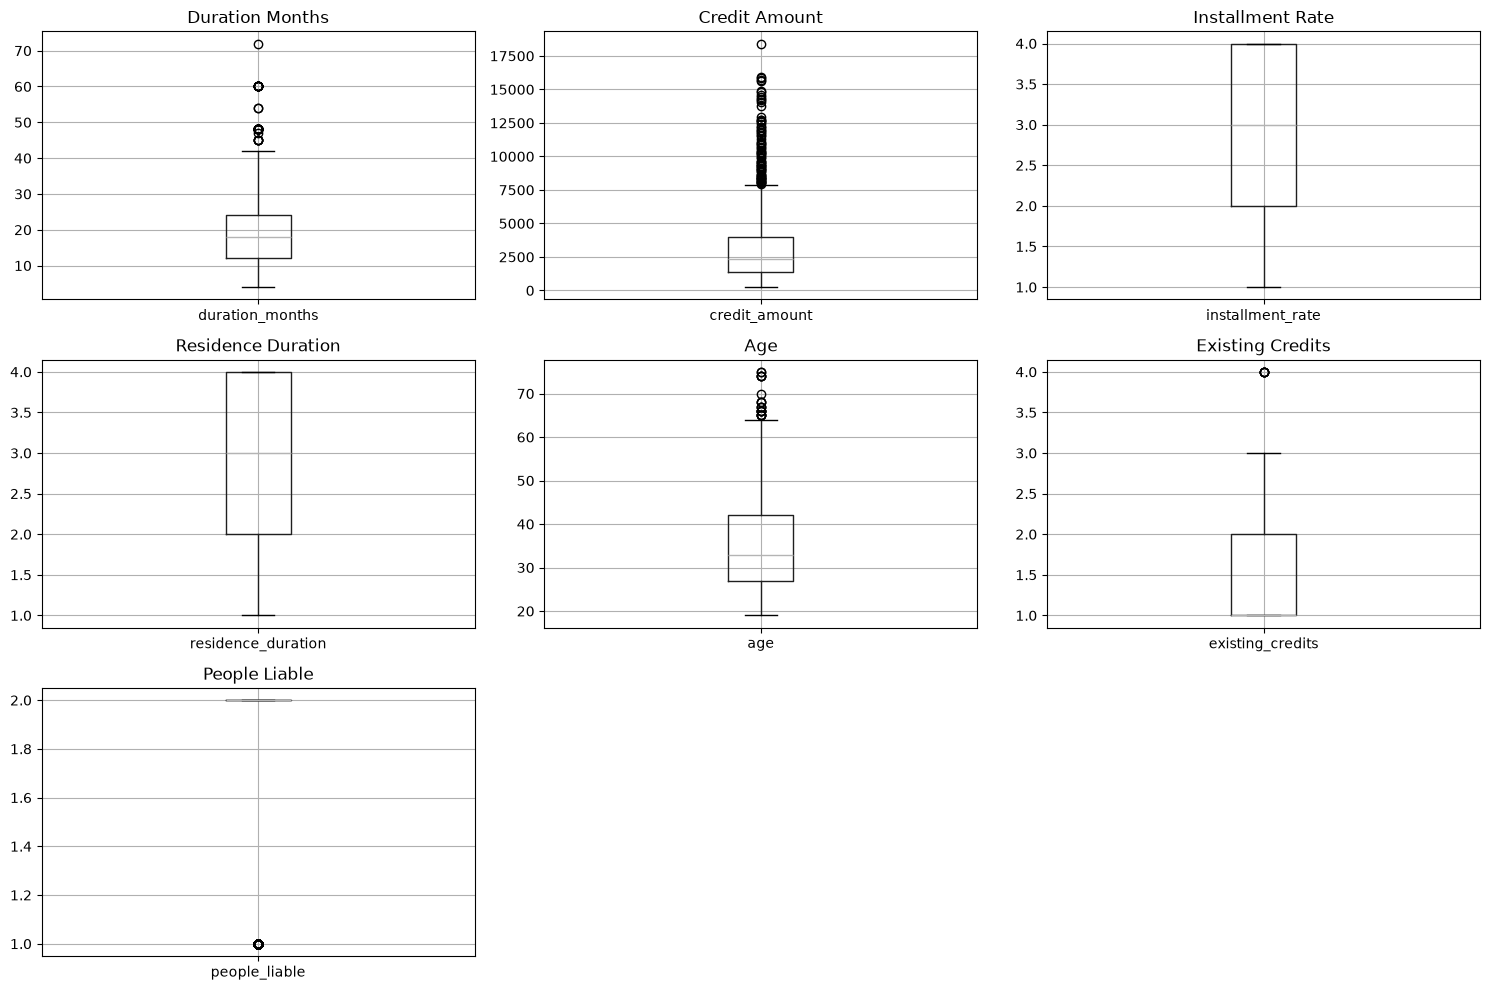

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, column in zip(axes, numeric_features, strict=False):
    df.boxplot(
        column=column,
        ax=ax,
    )

    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel("")

# Remove eixos vazios
for ax in axes[len(numeric_features) :]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Interpretação

Os boxplots indicam que algumas variáveis apresentam observações classificadas como valores extremos, principalmente **credit_amount**, **duration_months** e **age**.

Entretanto, esses valores não indicam necessariamente erros na base de dados. Em problemas de concessão de crédito, é esperado que alguns clientes solicitem empréstimos de valores elevados, possuam contratos de maior duração ou apresentem idades mais avançadas.

Além disso, observa-se que variáveis como **installment_rate**, **residence_duration**, **existing_credits** e **people_liable** possuem poucos valores possíveis, característica típica de variáveis discretas ou categóricas codificadas numericamente.

Neste projeto, os possíveis outliers serão mantidos na base de dados, uma vez que representam situações plausíveis do domínio de crédito e podem conter informações relevantes para a modelagem.

## Análise das Variáveis Categóricas

In [16]:
categorical_summary = []

for column in categorical_features:
    value_counts = df[column].value_counts()

    categorical_summary.append(
        {
            "Variável": column,
            "Nº de categorias": df[column].nunique(),
            "Categoria mais frequente": value_counts.index[0],
            "Frequência": value_counts.iloc[0],
            "Percentual (%)": round(
                value_counts.iloc[0] / len(df) * 100,
                2,
            ),
        }
    )

categorical_summary = (
    pd.DataFrame(categorical_summary)
    .sort_values("Nº de categorias", ascending=False)
    .reset_index(drop=True)
)

categorical_summary

,Variável,Nº de categorias,Categoria mais frequente,Frequência,Percentual (%)
0,credit_amount,923,1258,3,0.3
1,duration_months,33,24,184,18.4
2,purpose,10,3,280,28.0
3,credit_history,5,2,530,53.0
4,savings_account,5,1,603,60.3
5,employment_duration,5,3,339,33.9
6,checking_account,4,4,394,39.4
7,personal_status_sex,4,3,548,54.8
8,property,4,3,332,33.2
9,job,4,3,630,63.0


In [17]:
selected_categorical = [
    "checking_account",
    "credit_history",
    "purpose",
    "savings_account",
    "employment_duration",
    "housing",
]

### Distribuição das Principais Variáveis Categóricas

Após a análise geral das variáveis categóricas, foram selecionadas aquelas consideradas mais relevantes para o contexto de concessão de crédito.

O objetivo é compreender a distribuição das categorias mais representativas e identificar padrões que possam auxiliar na interpretação do perfil dos clientes antes da análise da relação com a variável alvo.

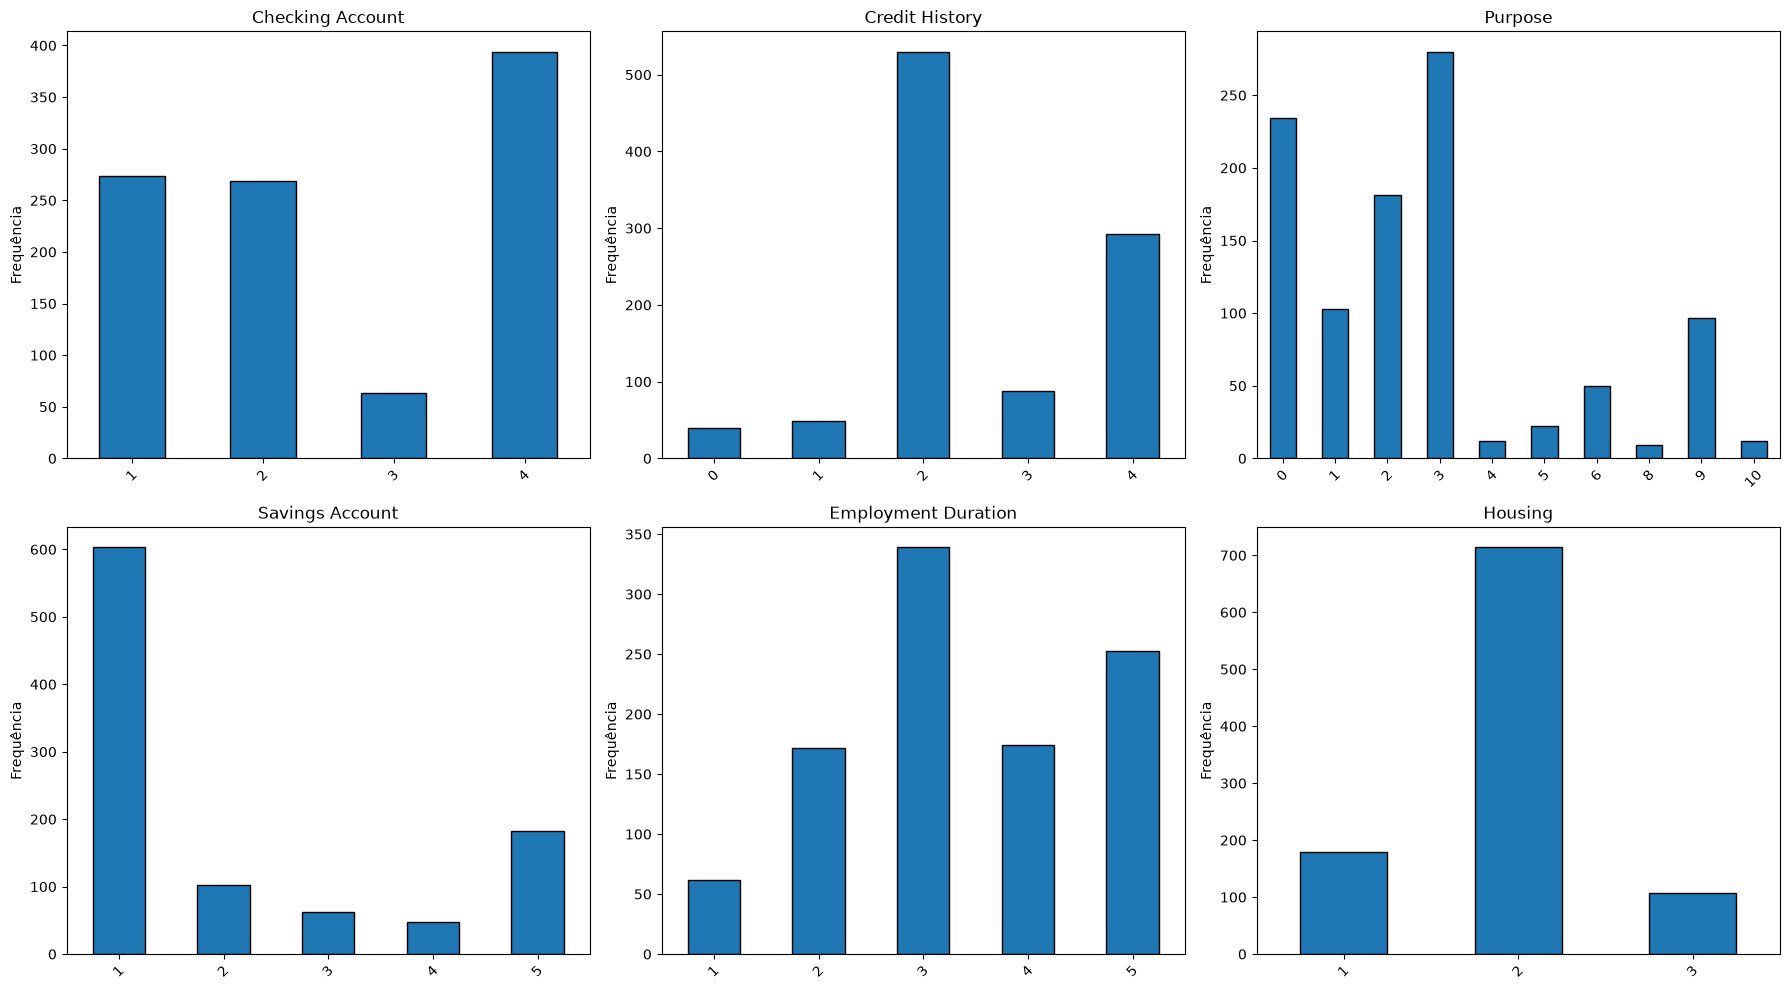

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, column in zip(axes, selected_categorical, strict=False):
    (
        df[column]
        .value_counts()
        .sort_index()
        .plot(
            kind="bar",
            ax=ax,
            edgecolor="black",
        )
    )

    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Frequência")
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(selected_categorical) :]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Interpretação

A análise das principais variáveis categóricas evidencia diferenças importantes na distribuição dos perfis dos clientes.

- **Checking Account:** observa-se maior concentração de clientes em poucas categorias de conta corrente, indicando que determinados perfis financeiros predominam na base.

- **Credit History:** a maior parte dos clientes apresenta histórico de crédito concentrado em uma categoria específica, enquanto históricos considerados menos frequentes representam uma parcela reduzida da população.

- **Purpose:** a finalidade do empréstimo apresenta maior diversidade entre as variáveis analisadas. Algumas finalidades concentram grande parte das solicitações, enquanto outras aparecem com baixa frequência.

- **Savings Account:** verifica-se forte concentração em uma única categoria, sugerindo que a maioria dos clientes possui perfil semelhante em relação à poupança.

- **Employment Duration:** o tempo de emprego apresenta distribuição relativamente equilibrada entre algumas categorias, embora exista predominância de determinados grupos.

- **Housing:** observa-se que uma categoria de moradia representa a maior parte dos clientes da base, indicando um perfil habitacional predominante.

De forma geral, as distribuições demonstram que algumas variáveis apresentam forte desbalanceamento entre categorias, característica comum em bases de crédito. Esses padrões serão investigados na próxima etapa, analisando sua relação com a variável alvo (**credit_risk**).